# Gemini MVP: define, submit, and analyze a logical task

## 1. Imports

In [1]:
from bloqade.gemini import logical as gemini_logical
from bloqade import squin, qubit

from bloqade.gemini import GeminiLogicalDevice

import numpy as np

import matplotlib.pyplot as plt

from typing import Any

from numpy.typing import NDArray

### 1.a. Some local config code for testing the code locally

#### For Local Testing
- Set `CONTEXT_NAME = "local-mock"`
- Move `mock-qlam-config.json` to `~/.qsh`, and rename it to `config.json`, so the final file is `~/.qsh/config.json`.
    - Alternatively, if you already have a `~/.qsh/config.json`, you can add the `"local-mock"` context to your existing `~/.qsh/config.json`.
- Run `python local_qlam_mock.py` to start a mock QLAM server.

#### For Testing on Gemini Device
- Set `CONTEXT_NAME = "gemini-logical-testing"`.
- Make sure that your `~/.qsh/config.json` file has a `"gemini-logical-testing"` context and is configured properly.

In [2]:
# CONTEXT_NAME = "gemini-logical-testing"
CONTEXT_NAME = "local-mock"

### 1.b. Setting config variables

In [3]:
NUM_SHOTS = 100
# NOTE: this is the team indicated in the Gemini Launch confluence page
TEAM = "team-alpha"
SQL_STORAGE_PATH = "gemini_mvp_demo_results.sql"
GEMINI_SLM_SITES = 160
GEMINI_PHYSICAL_GRID_ROWS = 5
GEMINI_PHYSICAL_GRID_COLS = 16
GEMINI_PHYSICAL_QUBITS = GEMINI_SLM_SITES // 2

## 2. Define task submission + data retrieval pipeline

In [4]:
# TODO: can change to "testbed", but only works for QASM
device = GeminiLogicalDevice(context_name=CONTEXT_NAME)

In [5]:
def physical_qubit_shots_from_slm(
    slm_shots
) -> np.ndarray:
    """
    Takes the even-indexed SLM sites.
    """

    shots = np.asarray(slm_shots, dtype=bool)
    if shots.ndim != 2:
        raise ValueError(
            f"Expected a 2D shot array shaped (shots, slm_sites), got {shots.shape}."
        )

    if shots.shape[1] != GEMINI_SLM_SITES:
        raise ValueError(
            f"Expected {GEMINI_SLM_SITES} SLM sites, got {shots.shape[1]}."
        )

    return shots[:, ::2]

In [6]:
# TODO: can break this into more functions depending on what you want to separate, but for now to reduce the amount of code written, the pipeline is just in one function.
# TODO: can probably type-check more generic types for device and storage? but it's OK for demo
def run_pipeline(kernel: Any, program_name: str, device: GeminiLogicalDevice, timeout: float = 80.0) -> NDArray[np.bool_]:
    """
    Creates a task, submits it, and extracts the shot results on the physical qubits.
    """
    kernel.print()
    task = device.task(
        kernel=kernel,
        num_shots=NUM_SHOTS,
        metadata={
            "team": TEAM,
            "demo": "gemini-mvp",
            "program": program_name,
        },
        # TODO: program_language is squin or gemini_logical ?
        program_language=kernel.sym_name,
    )
    # Dry run; prints out the task
    task.run_async(dry_run=True)
    future = task.run_async(dry_run=False)
    # TODO: "arbitrary" timeout of 80 seconds
    result = future.result(timeout=timeout)
    shot_batches = result.shot_results()
    raw_slm_shots = shot_batches[0]
    if raw_slm_shots.size == 0:
        physical_shots = np.empty((0, GEMINI_PHYSICAL_QUBITS), dtype=bool)
    else:
        # NOTE: just getting even indexed qubits, not in a particular order
        physical_shots = physical_qubit_shots_from_slm(raw_slm_shots)
    return physical_shots

## 3. Define kernels to run

In [7]:
@gemini_logical.kernel(aggressive_unroll=True, verify=True)
def global_pi_half_pulse():
    reg = qubit.qalloc(5)
    squin.broadcast.sqrt_x(reg)
    return gemini_logical.terminal_measure(reg)

In [8]:
@gemini_logical.kernel(aggressive_unroll=True, verify=True)
def global_pi_pulse():
    reg = qubit.qalloc(5)
    squin.broadcast.x(reg)
    return gemini_logical.terminal_measure(reg)

In [9]:
@gemini_logical.kernel(aggressive_unroll=True, verify=True)
def global_no_pulse():
    reg = qubit.qalloc(5)
    return gemini_logical.terminal_measure(reg)

## 4. Submit kernel and retrieve results for global pi/2 pulse

In [10]:
# Print the Gemini Logical kernel
global_pi_half_pulse.print()

func.func @global_pi_half_pulse() -> !py.IList[!py.IList[!py.MeasurementResult, !Any], Literal(5,int)] {
  ^0(%global_pi_half_pulse_self):
  │   %0 = qubit.new() : !py.Qubit
  │   %1 = qubit.new() : !py.Qubit
  │   %2 = qubit.new() : !py.Qubit
  │   %3 = qubit.new() : !py.Qubit
  │   %4 = qubit.new() : !py.Qubit
  │ %reg = py.ilist.new(values=(%0, %1, %2, %3, %4)){elem_type=!Any} : !py.IList[!py.Qubit, Literal(5,int)]
  │        squin.gate.sqrt_x(qubits=%reg){adjoint=False : !py.bool}
  │   %5 = logical.terminal_logical_measurement(qubits=%reg){num_physical_qubits=7 : !py.int} : !py.IList[!py.IList[!py.MeasurementResult, !Any], Literal(5,int)]
  │        func.return %5
} // func.func global_pi_half_pulse


In [11]:
# Define the Gemini Logical task
task = device.task(
    kernel=global_pi_half_pulse,
    num_shots=NUM_SHOTS,
    metadata={
        "team": TEAM,
        "demo": "gemini-mvp",
        "program": "global-pi-half-pulse",
    },
    # TODO: program_language is squin or gemini_logical ?
    program_language=global_pi_half_pulse.sym_name,
)

In [12]:
# Test to see what task we expect to submit
task.run_async(dry_run=True)

DRY RUN -- NO PROGRAM WAS ACTUALLY SUBMITTED FOR EXECUTION
Would now submit a task containing a single subtask for the kernel:
  * global_pi_half_pulse() - 100 shots
Set dry_run=False to actually execute this kernel.


In [13]:
# Submit the task
future = task.run_async(dry_run=False)

2026-06-03 11:46:51.276 | INFO     | bloqade.core.device.task:submit_task_definition:326 - Submitted task with ID: 9b2f1f0e-43ef-46bc-bd36-a73a88602365


In [14]:
# Retrieve the task with a timeout of 80 seconds (is blocking)
result = future.result(timeout=80.0)

2026-06-03 11:46:51.686 | INFO     | bloqade.core.device.future:get_task:98 - Fetched task with id 9b2f1f0e-43ef-46bc-bd36-a73a88602365. Current status: TaskStatus.COMPLETED


In [15]:
# Retrieve the shot results
shot_batches = result.shot_results()


In [16]:
# Get the shots for this task, and obtain shots for left SLM sites
raw_slm_shots = shot_batches[0]
if raw_slm_shots.size == 0:
    physical_shots_pi_half = np.empty((0, GEMINI_PHYSICAL_QUBITS), dtype=bool)
else:
    # NOTE: just getting even indexed qubits, not in a particular order
    physical_shots_pi_half = physical_qubit_shots_from_slm(raw_slm_shots)

## 4.b. Use helper function to submit kernels and retrieve results

In [17]:
physical_shots_pi = run_pipeline(global_pi_pulse, "global-pi-pulse", device)

func.func @global_pi_pulse() -> !py.IList[!py.IList[!py.MeasurementResult, !Any], Literal(5,int)] {
  ^0(%global_pi_pulse_self):
  │   %0 = qubit.new() : !py.Qubit
  │   %1 = qubit.new() : !py.Qubit
  │   %2 = qubit.new() : !py.Qubit
  │   %3 = qubit.new() : !py.Qubit
  │   %4 = qubit.new() : !py.Qubit
  │ %reg = py.ilist.new(values=(%0, %1, %2, %3, %4)){elem_type=!Any} : !py.IList[!py.Qubit, Literal(5,int)]
  │        squin.gate.x(qubits=%reg)
  │   %5 = logical.terminal_logical_measurement(qubits=%reg){num_physical_qubits=7 : !py.int} : !py.IList[!py.IList[!py.MeasurementResult, !Any], Literal(5,int)]
  │        func.return %5
} // func.func global_pi_pulse


2026-06-03 11:46:55.491 | INFO     | bloqade.core.device.task:submit_task_definition:326 - Submitted task with ID: 03851d7d-e398-4062-ae79-e7ba2c9f7d63
2026-06-03 11:46:55.495 | INFO     | bloqade.core.device.future:get_task:98 - Fetched task with id 03851d7d-e398-4062-ae79-e7ba2c9f7d63. Current status: TaskStatus.COMPLETED


DRY RUN -- NO PROGRAM WAS ACTUALLY SUBMITTED FOR EXECUTION
Would now submit a task containing a single subtask for the kernel:
  * global_pi_pulse() - 100 shots
Set dry_run=False to actually execute this kernel.


In [18]:
physical_shots_no_pulse = run_pipeline(global_no_pulse, "global-no-pulse", device)

func.func @global_no_pulse() -> !py.IList[!py.IList[!py.MeasurementResult, !Any], Literal(5,int)] {
  ^0(%global_no_pulse_self):
  │   %0 = qubit.new() : !py.Qubit
  │   %1 = qubit.new() : !py.Qubit
  │   %2 = qubit.new() : !py.Qubit
  │   %3 = qubit.new() : !py.Qubit
  │   %4 = qubit.new() : !py.Qubit
  │ %reg = py.ilist.new(values=(%0, %1, %2, %3, %4)){elem_type=!Any} : !py.IList[!py.Qubit, Literal(5,int)]
  │   %5 = logical.terminal_logical_measurement(qubits=%reg){num_physical_qubits=7 : !py.int} : !py.IList[!py.IList[!py.MeasurementResult, !Any], Literal(5,int)]
  │        func.return %5
} // func.func global_no_pulse


2026-06-03 11:46:55.994 | INFO     | bloqade.core.device.task:submit_task_definition:326 - Submitted task with ID: c965dd4a-d12b-48a5-b86b-00cd5c81614d
2026-06-03 11:46:55.998 | INFO     | bloqade.core.device.future:get_task:98 - Fetched task with id c965dd4a-d12b-48a5-b86b-00cd5c81614d. Current status: TaskStatus.COMPLETED


DRY RUN -- NO PROGRAM WAS ACTUALLY SUBMITTED FOR EXECUTION
Would now submit a task containing a single subtask for the kernel:
  * global_no_pulse() - 100 shots
Set dry_run=False to actually execute this kernel.


#### Verify data type of shots

In [19]:
print(physical_shots_no_pulse.shape)
print(physical_shots_no_pulse.dtype)

(100, 80)
bool


## 5. Postprocess and plot results

In [20]:
def physical_qubit_grid_from_shots(
    shots: np.ndarray,
    *,
    rows: int = GEMINI_PHYSICAL_GRID_ROWS,
    cols: int = GEMINI_PHYSICAL_GRID_COLS,
) -> np.ndarray:
    shots = np.asarray(shots, dtype=bool)
    if shots.ndim != 2:
        raise ValueError(f"Expected a 2D shot array, got {shots.shape}.")

    expected_qubits = rows * cols
    if shots.shape[1] != expected_qubits:
        raise ValueError(
            f"Expected {expected_qubits} physical-qubit columns, got {shots.shape[1]}."
        )

    return shots.reshape(shots.shape[0], rows, cols)

def zero_probability_grid_from_shots(
    shots: np.ndarray,
    *,
    rows: int = GEMINI_PHYSICAL_GRID_ROWS,
    cols: int = GEMINI_PHYSICAL_GRID_COLS,
) -> np.ndarray:
    shot_grid = physical_qubit_grid_from_shots(shots, rows=rows, cols=cols)
    if shot_grid.shape[0] == 0:
        return np.zeros(
            (rows, cols)
        )

    return np.mean(~shot_grid, axis=0)

def global_measurement_probabilities(shots: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Plots the marginal distribution across all qubits of measuring 0.
    """
    shots = np.asarray(shots, dtype=bool)
    if shots.ndim != 2:
        raise ValueError(f"Expected a 2D shot array, got {shots.shape}.")

    counts = np.array(
        [np.count_nonzero(~shots), np.count_nonzero(shots)],
        dtype=float,
    )
    total = counts.sum()
    probabilities = counts / total if total else np.zeros(2)
    return counts, probabilities

def subset_shot_columns(
    shots: np.ndarray,
    *,
    rows: int = GEMINI_PHYSICAL_GRID_ROWS,
    cols: int = GEMINI_PHYSICAL_GRID_COLS,
):
    """
    Obtain only the first 7 columns from the resulting shot array.
    """
    shot_grid = physical_qubit_grid_from_shots(shots, rows=rows, cols=cols)
    # Special logic to only choose first 7 columns
    shot_grid = shot_grid[:, :, :int(GEMINI_PHYSICAL_GRID_COLS / 2 - 1)]
    return shot_grid.reshape(shot_grid.shape[0], -1)

def plot_physical_measurement_summary_row(
    physical_shot_batches: list[np.ndarray],
    *,
    labels: list[str] | None = None,
) -> None:
    """
    Takes in shots from multiple kernels, and plots both the heatmaps and the marginal distribution for each set of shots.
    """
    if not physical_shot_batches:
        raise ValueError("Expected at least one physical shot array.")

    if labels is None:
        labels = [f"kernel {idx}" for idx in range(len(physical_shot_batches))]

    if len(labels) != len(physical_shot_batches):
        raise ValueError(
            f"Expected {len(physical_shot_batches)} labels, got {len(labels)}."
        )

    fig, axes = plt.subplots(
        2,
        len(physical_shot_batches),
        figsize=(5.5 * len(physical_shot_batches) + 1.0, 7.0),
        squeeze=False,
    )

    image = None

    heatmap_rows = GEMINI_PHYSICAL_GRID_ROWS
    heatmap_cols = int(GEMINI_PHYSICAL_GRID_COLS / 2 - 1)
    
    for heatmap_ax, histogram_ax, shots, label in zip(
        axes[0], axes[1], physical_shot_batches, labels
    ):
        shots = subset_shot_columns(shots)
        zero_probability = zero_probability_grid_from_shots(shots, rows=heatmap_rows, cols=heatmap_cols)
        image = heatmap_ax.imshow(
            zero_probability,
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
            origin="lower",
            aspect="auto",
        )
        heatmap_ax.set_title(label)
        heatmap_ax.set_xlabel("physical-qubit column")
        heatmap_ax.set_xticks(np.arange(heatmap_cols))
        heatmap_ax.set_yticks(np.arange(heatmap_rows))

        counts, probabilities = global_measurement_probabilities(shots)
        bars = histogram_ax.bar(
            ["0", "1"], probabilities, color=["#6b7280", "#2f6f73"]
        )
        histogram_ax.set_xlabel("measurement value")
        histogram_ax.set_ylim(0, 1)
        histogram_ax.set_title(label)

        for bar, count, probability in zip(bars, counts.astype(int), probabilities):
            histogram_ax.text(
                bar.get_x() + bar.get_width() / 2,
                min(probability + 0.03, 0.98),
                f"{probability:.3f}\n(n={count})",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    axes[0, 0].set_ylabel("physical-qubit row")
    axes[1, 0].set_ylabel("probability over all shot-qubit samples")
    fig.suptitle("Physical-qubit measurement summary")
    fig.tight_layout(rect=[0.0, 0.0, 0.92, 0.95])
    if image is not None:
        colorbar_ax = fig.add_axes([0.94, 0.54, 0.012, 0.30])
        fig.colorbar(
            image,
            cax=colorbar_ax,
            label="P(measurement = 0)",
        )
    plt.show()

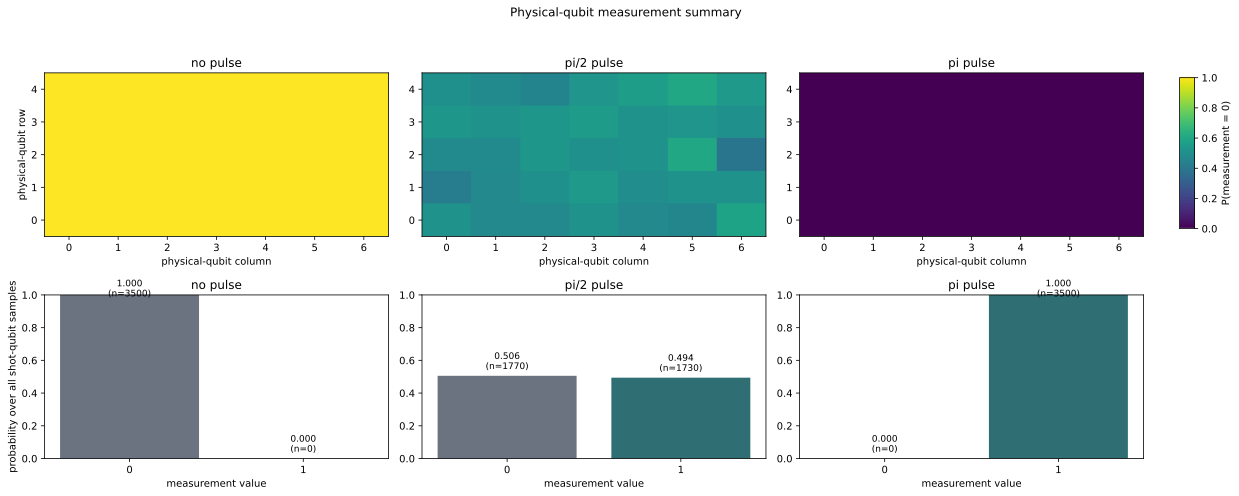

In [21]:
plot_physical_measurement_summary_row(
    [physical_shots_no_pulse, physical_shots_pi_half, physical_shots_pi],
    labels=["no pulse", "pi/2 pulse", "pi pulse"],
)